### Business Understanding 

Problem Statement: 
Empirical analysis: Behavioural Brain dysfunction and EEG based analysis on drugs in machine learning

Dataset Information: 
#### Feature Attributes for Quantified Data:

1. ID: is a number of records in an original database. Cannot be related to the participant. It can be used for reference only.
2. Age (Real) is the age of participant
3. Gender: Male or Female
4. Education: level of education of participant
5. Country: country of origin of the participant
6. Ethnicity: ethnicity of participant
7. Nscore (Real) is NEO-FFI-R Neuroticism
8. Escore (Real) is NEO-FFI-R Extraversion
9. Oscore (Real) is NEO-FFI-R Openness to experience.
10. Ascore (Real) is NEO-FFI-R Agreeableness.
11. Cscore (Real) is NEO-FFI-R Conscientiousness.
12. Impulsive (Real) is impulsiveness measured by BIS-11
13. SS (Real) is sensation seeing measured by ImpSS
14. Alcohol: alcohol consumption


#### Rating's for Drug Use:

- CL0 Never Used
- CL1 Used over a Decade Ago
- CL2 Used in Last Decade
- CL3 Used in Last Year 59
- CL4 Used in Last Month
- CL5 Used in Last Week
- CL6 Used in Last Day

Goal: Checking the Behavioral Pattern of an Alcohol User

- Isolate User Groups: First, we filter the dataset to create distinct groups based on alcohol consumption frequency (e.g., 'Used in Last Week', 'Used in Last Month', 'Never Used').

- Analyze Demographics: For each group, we can plot the distribution of demographic data like Age, Gender, and Education Level. This would answer questions like, "Which age group reports the most frequent alcohol consumption?"

- Analyze Personality Traits: The most powerful insight comes from comparing personality scores across these groups. By creating boxplots for scores like Neuroticism (Nscore), Extraversion (Escore), Openness (Oscore), Sensation Seeking (SS), and Impulsivity, we can identify specific traits associated with alcohol use. For example, we might find that individuals who score higher on Sensation Seeking and Impulsivity are more likely to be recent and frequent alcohol users.

In [2]:
import pandas as pd
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings
warnings.filterwarnings('ignore') 

In [3]:
# Import the dataset 
df = pd.read_csv('/data/Drug_Consumption.csv')
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/data/Drug_Consumption.csv'

In [70]:
df.columns

Index(['ID', 'Age', 'Gender', 'Education', 'Country', 'Ethnicity', 'Nscore',
       'Escore', 'Oscore', 'AScore', 'Cscore', 'Impulsive', 'SS', 'Alcohol',
       'Amphet', 'Amyl', 'Benzos', 'Caff', 'Cannabis', 'Choc', 'Coke', 'Crack',
       'Ecstasy', 'Heroin', 'Ketamine', 'Legalh', 'LSD', 'Meth', 'Mushrooms',
       'Nicotine', 'Semer', 'VSA'],
      dtype='object')

In [71]:
# Remove unnecessary columns to perform target analysis on Alcohol consumption
df.drop(columns=['ID' , 'Amphet', 'Amyl', 'Benzos', 'Caff', 'Cannabis', 'Choc', 'Coke', 'Crack',
       'Ecstasy', 'Heroin', 'Ketamine', 'Legalh', 'LSD', 'Meth', 'Mushrooms',
       'Nicotine', 'Semer', 'VSA'] , axis=1, inplace=True)

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1884 entries, 0 to 1883
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        1884 non-null   object 
 1   Gender     1884 non-null   object 
 2   Education  1884 non-null   object 
 3   Country    1884 non-null   object 
 4   Ethnicity  1884 non-null   object 
 5   Nscore     1884 non-null   float64
 6   Escore     1884 non-null   float64
 7   Oscore     1884 non-null   float64
 8   AScore     1884 non-null   float64
 9   Cscore     1884 non-null   float64
 10  Impulsive  1884 non-null   float64
 11  SS         1884 non-null   float64
 12  Alcohol    1884 non-null   object 
dtypes: float64(7), object(6)
memory usage: 191.5+ KB


In [73]:
df.shape

(1884, 13)

### Exploratory Data Analysis

In [74]:
df.isnull().any().sum()

np.int64(0)

In [75]:
df.duplicated().any()

np.False_

In [76]:
df.nunique()

Age           6
Gender        2
Education     9
Country       7
Ethnicity     7
Nscore       49
Escore       42
Oscore       35
AScore       41
Cscore       41
Impulsive    10
SS           11
Alcohol       7
dtype: int64

In [77]:
df['Alcohol'].value_counts()

Alcohol
CL5    758
CL6    505
CL4    287
CL3    198
CL2     68
CL1     34
CL0     34
Name: count, dtype: int64

In [78]:
# Mapping the Alcohol consumption values to more readable categories
alcohol_mapping = {
        'CL0': 'Never Used', 'CL1': 'Over a Decade Ago', 'CL2': 'In Last Decade',
        'CL3': 'In Last Year', 'CL4': 'In Last Month', 'CL5': 'In Last Week',
        'CL6': 'In Last Day'
    }

df['Alcohol'] = df['Alcohol'].map(alcohol_mapping)
df['Alcohol'].value_counts()

Alcohol
In Last Week         758
In Last Day          505
In Last Month        287
In Last Year         198
In Last Decade        68
Over a Decade Ago     34
Never Used            34
Name: count, dtype: int64

In [79]:
df['Age'].value_counts().sort_index()

Age
18-24    643
25-34    481
35-44    355
45-54    294
55-64     93
65+       18
Name: count, dtype: int64

In [80]:
category_order = list(alcohol_mapping.values())

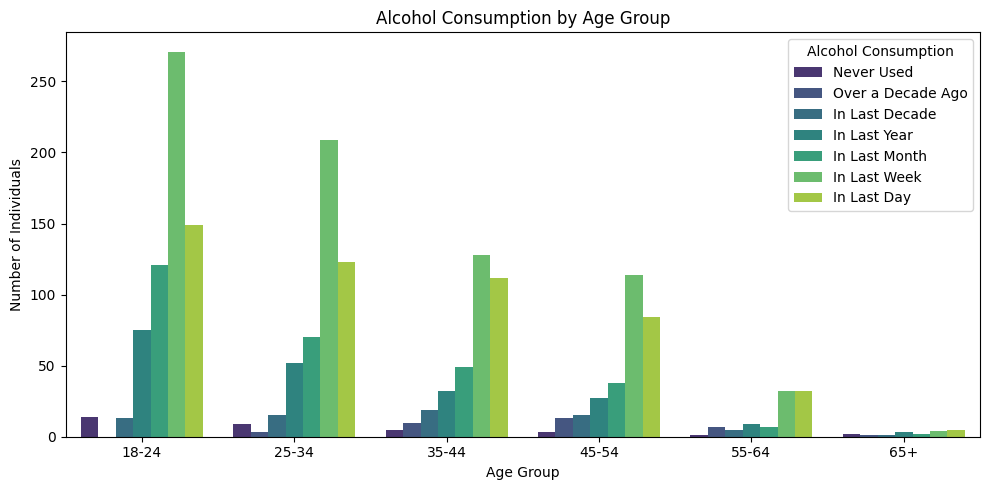

In [81]:
# Display Demographic Information
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Age', hue='Alcohol', palette='viridis' ,hue_order=category_order,order=sorted(df['Age'].unique()))
plt.title('Alcohol Consumption by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Individuals')
plt.legend(title='Alcohol Consumption')
plt.tight_layout()
plt.savefig('images/alcohol_consumption_by_age.png')
plt.show()

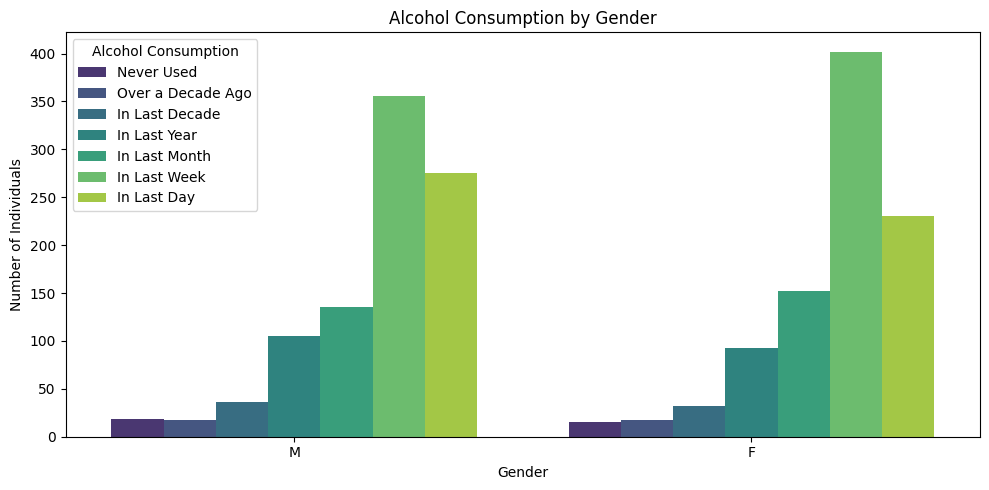

In [82]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Gender', hue='Alcohol', palette='viridis' , hue_order=category_order)
plt.title('Alcohol Consumption by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Individuals')
plt.legend(title='Alcohol Consumption')
plt.tight_layout()
plt.savefig('images/alcohol_consumption_by_gender.png')
plt.show()

The trend shows that alcohol consumption is most frequent among younger age groups (18–24 and 25–34), with a sharp decline in older age groups (55–64 and 65+).

Across genders, both males and females report high recent usage, but males show slightly higher counts in frequent consumption (daily/weekly), while females show comparable levels in occasional categories (monthly/yearly).

In [83]:
# Create function to isolate alcohol user and non-user groups
def alcohol_user_groups(df):
    category=[]
    for i in df['Alcohol']:
        if i in ['Never Used', 'Over a Decade Ago' , 'In Last Decade']:
            category.append('Non-User')
        else:
            category.append('User')
    return category

df['Alcohol_Group'] = alcohol_user_groups(df) 

In [85]:
df['Alcohol_Group'].value_counts()

Alcohol_Group
User        1748
Non-User     136
Name: count, dtype: int64

<Axes: xlabel='Age', ylabel='count'>

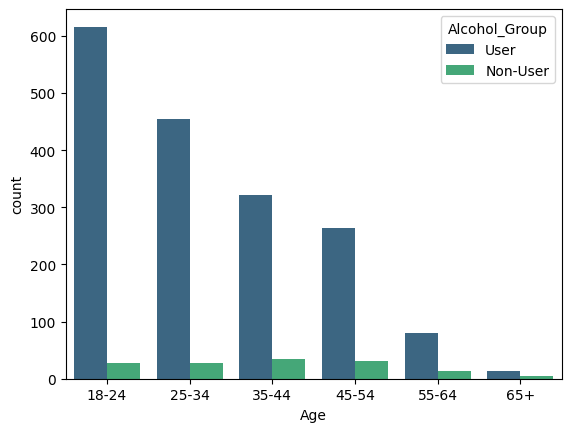

In [ ]:
ax = sns.countplot(data=df, x='Age', palette='viridis' , hue='Alcohol_Group' , order=sorted(df['Age'].unique()))
ax.collection[0]

In [87]:
df.columns

Index(['Age', 'Gender', 'Education', 'Country', 'Ethnicity', 'Nscore',
       'Escore', 'Oscore', 'AScore', 'Cscore', 'Impulsive', 'SS', 'Alcohol',
       'Alcohol_Group'],
      dtype='object')

In [93]:
df.rename(columns={'AScore': 'Ascore'}, inplace=True)

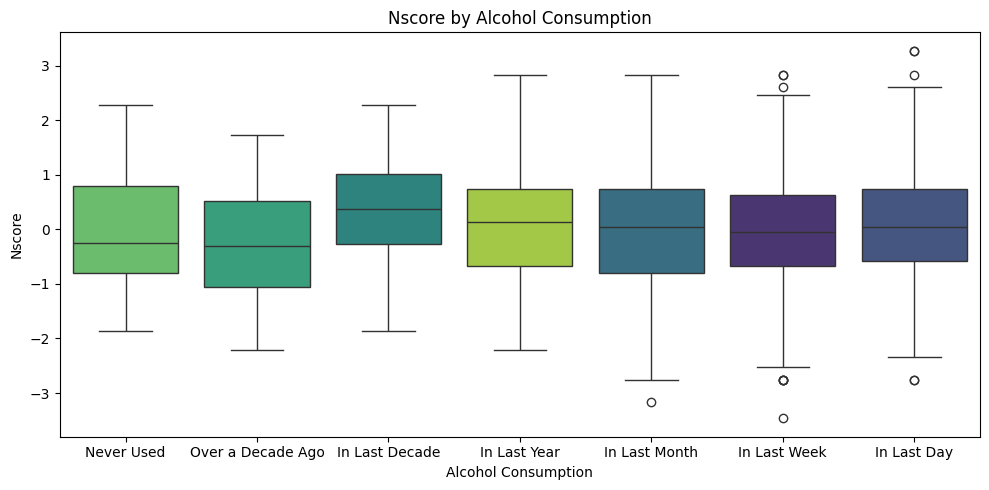

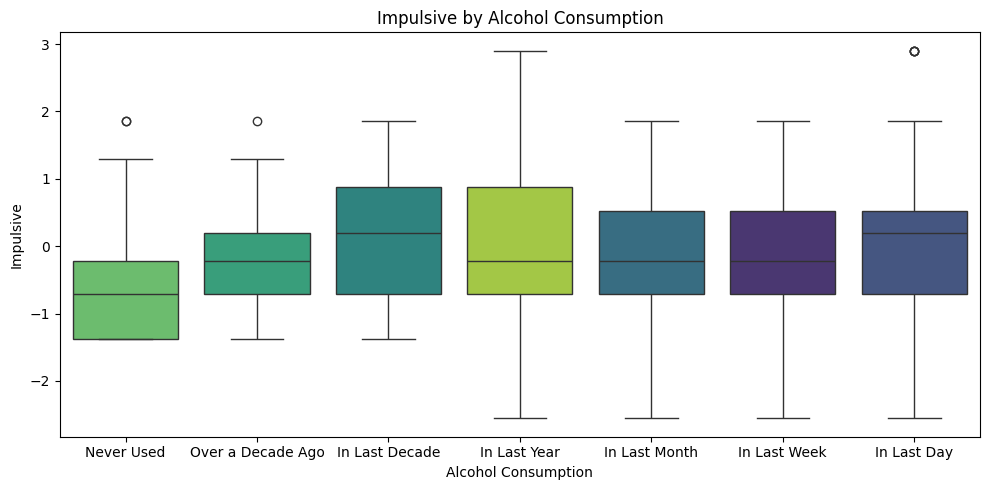

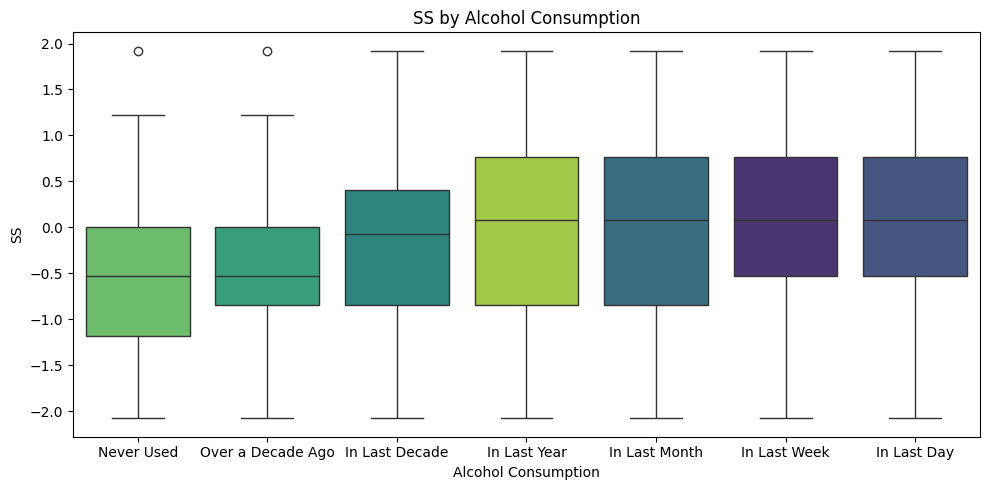

In [102]:
# Compare Personality Traits between Alcohol Users and Non-Users
personality_traits = ['Nscore', 'Impulsive', 'SS'] 
for trait in personality_traits:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df, x='Alcohol', y=trait, palette='viridis' , hue='Alcohol', order=category_order)
    plt.title(f'{trait} by Alcohol Consumption')
    plt.xlabel('Alcohol Consumption')
    plt.ylabel(trait)
    plt.tight_layout()
    plt.savefig(f'images/{trait}_by_alcohol_consum.png')
    plt.show()

#### Impact on Cognition:
1. Neuroticism (Nscore)

        Low Nscore → better emotional regulation, less stress interference with working memory.
        High Nscore (seen in alcoholics) → more emotional reactivity, impaired decision-making, and reduced cognitive flexibility.

2. Impulsivity

        Low impulsivity → stronger executive control, better planning, less risky decision-making.
        High impulsivity (alcoholics) → poorer self-control, impaired inhibitory mechanisms, higher likelihood of risky behaviors that overload cognitive systems.

3. Sensation-Seeking (SS)

        Low SS → stable attention, consistent long-term goal focus.
        High SS (alcoholics) → stronger dopamine-driven reward sensitivity, leading to distractibility, risk-taking, and disrupted learning processes.

### Conclusion

The trends suggest that non-users(Never Used/Over a decade ago) show a protective cognitive profile (lower impulsivity, sensation-seeking, and emotional instability), supporting stronger brain function. 

In contrast, alcohol users(Last Day/Week/Month) especially frequent users—display personality traits linked with impaired executive control, emotional regulation difficulties, and riskier decision-making, indicating higher susceptibility to cognitive dysfunction.